# Simulação de Primeiras Chegadas

Este Jupyter Notebook contém os códigos necessários para construir um modelo geológico e plotar o gráfico tempo x distância para simular o resultado de um levantamento sísmico de refração com dois tiros.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [2]:
def simulate_two_shots(layer_thickness, layer_velocities, layer_slopes, source_positions, receiver_positions):
    """
    Simula os tempos de primeira chegada para dois tiros em um modelo sísmico com camadas inclinadas ou horizontais.

    Parameters:
    - layer_thickness: Lista com espessuras das camadas na posição x=0 (m).
    - layer_velocities: Lista com velocidades das camadas (m/s).
    - layer_slopes: Lista com ângulos de inclinação das interfaces (graus). Se zero, simula camadas horizontais.
    - source_positions: Lista de tuplas (x, z) com as posições das fontes (m).
    - receiver_positions: Lista de tuplas (x, z) com posições dos receptores (m).

    Returns:
    - all_times: Lista de listas com os tempos de primeira chegada para cada tiro (s).
    - all_labels: Lista de listas com os tipos de onda ('Camada 1', 'Camada 2', ...) para cada tiro.
    """
    # Pré-calcula valores fixos para todos os tiros
    slopes_rad = [np.radians(slope) for slope in layer_slopes]
    interfaces_z0 = np.cumsum([0] + layer_thickness)  # Profundidade das interfaces em x=0

    # Simula cada tiro
    all_times = []
    all_labels = []
    for source_pos in source_positions:
        times = []
        labels = []
        for rx, rz in receiver_positions:
            # Distância horizontal entre fonte e receptor
            dx = rx - source_pos[0]
            dx_abs = abs(dx)
            
            # Calcula o tempo da onda da Camada 1 (onda direta)
            dist_direct = np.sqrt(dx**2 + (rz - source_pos[1])**2)
            t_direct = dist_direct / layer_velocities[0]
            
            # Inicializa o menor tempo e a label correspondente
            min_time = t_direct
            min_label = 'Camada 1'
            
            # Calcula tempos de refração para cada camada (a partir da camada 2)
            for i in range(len(layer_thickness)):
                # Camada refratada (i+1 é a camada de refração)
                refr_layer = i + 1
                v_refr = layer_velocities[refr_layer]  # Velocidade da camada refratada
                if v_refr <= layer_velocities[0]:
                    continue  # Pula se a velocidade não for maior que a camada 1
                
                # Calcula o ângulo crítico para a refração (usando a velocidade da camada 1)
                sin_crit = layer_velocities[0] / v_refr
                if sin_crit >= 1:
                    continue  # Não há refração crítica
                
                # Evita erros numéricos se sin_crit for muito próximo de 1
                sin_crit = min(sin_crit, 0.999999)
                cos_crit = np.sqrt(1 - sin_crit**2)
                
                # Tempo total: soma do caminho de ida, refração e volta
                t_refr = 0
                # Calcula a profundidade média da interface refratada
                z_refr_source = interfaces_z0[i+1] + source_pos[0] * np.tan(slopes_rad[i])
                z_refr_receiver = interfaces_z0[i+1] + rx * np.tan(slopes_rad[i])
                h_avg = (z_refr_source + z_refr_receiver) / 2  # Profundidade média
                
                # Tempo para os caminhos de ida e volta (considerando apenas a camada 1 para simplificar)
                t_refr += 2 * h_avg * cos_crit / layer_velocities[0]
                
                # Ajuste para a inclinação ao longo da interface refratada
                slope_refr = slopes_rad[i]  # Inclinação da interface refratada
                direction_factor = 1 if dx >= 0 else -1  # Positivo se receptor está à direita da fonte
                # Tempo ao longo da interface refratada
                t_refr += (dx_abs / v_refr) * np.cos(slope_refr)  # Componente horizontal ajustada pela inclinação
                t_refr += direction_factor * (dx_abs * np.sin(slope_refr) * sin_crit / layer_velocities[0])  # Termo de assimetria
                
                # Verifica se o tempo de refração é o menor
                if t_refr < min_time:
                    min_time = t_refr
                    min_label = f'Camada {refr_layer + 1}'
            
            times.append(min_time)
            labels.append(min_label)
        
        all_times.append(times)
        all_labels.append(labels)

    return all_times, all_labels

In [3]:
def plot_seismic_profile(layer_thickness, layer_velocities, layer_slopes, source_positions, receiver_positions):
    """
    Plota um esquema do perfil geológico da simulação sísmica, mostrando múltiplas fontes.

    Parameters:
    - layer_thickness: Lista com espessuras das camadas na posição x=0 (m).
    - layer_velocities: Lista com velocidades das camadas (m/s).
    - layer_slopes: Lista com ângulos de inclinação das interfaces (graus).
    - source_positions: Lista de tuplas (x, z) com as posições das fontes (m).
    - receiver_positions: Lista de tuplas (x, z) com posições dos receptores (m).
    """
    # Configura a figura
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define limites do gráfico
    x_min = min(min([rx for rx, _ in receiver_positions]), min([sx for sx, _ in source_positions])) - 5
    x_max = max(max([rx for rx, _ in receiver_positions]), max([sx for sx, _ in source_positions])) + 5
    z_max = sum(layer_thickness) * 1.5  # Margem para camadas mais profundas
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-5, z_max)
    ax.invert_yaxis()  # Profundidade positiva para baixo
    ax.set_xlabel('Distância (m)')
    ax.set_ylabel('Profundidade (m)')
    ax.set_title('Perfil Geológico da Simulação Sísmica')
    ax.grid(True, alpha=0.3)

    # Define cores em tons pastéis correspondentes ao gráfico de primeiras chegadas
    pastel_colors = {
        'Camada 1': 'lightblue',   # Tom pastel para azul
        'Camada 2': 'peachpuff',  # Tom pastel para laranja
        'Camada 3': 'lightcoral', # Tom pastel para vermelho
        'Camada 4': 'lightgreen',  # Tom pastel para verde
        'Camada 5': 'lavender'     # Tom pastel para roxo
    }

    # Preenchimento das camadas com cores pastéis
    slopes_rad = [np.radians(slope) for slope in layer_slopes]
    interfaces_z0 = np.cumsum([0] + layer_thickness)  # Profundidade na origem (x=0)
    
    x_vals = np.linspace(x_min, x_max, 100)  # Pontos para suavizar o preenchimento
    
    # Camada 1: Entre superfície (z=0) e primeira interface
    z_upper = np.zeros_like(x_vals)  # Superfície
    if len(interfaces_z0) > 1:
        z_lower = interfaces_z0[1] + x_vals * np.tan(slopes_rad[0])
        ax.fill_between(x_vals, z_upper, z_lower, color=pastel_colors['Camada 1'], alpha=0.4, label='Camada 1')
    
    # Camadas intermediárias e última camada
    for i in range(len(interfaces_z0)-1):
        # Interface superior da camada atual (i+1 é o índice da interface superior)
        z_upper = interfaces_z0[i+1] + x_vals * np.tan(slopes_rad[i])
        # Interface inferior: próxima interface ou fundo do gráfico
        if i+2 < len(interfaces_z0):
            z_lower = interfaces_z0[i+2] + x_vals * np.tan(slopes_rad[i+1])
        else:
            z_lower = np.full_like(x_vals, z_max)  # Última camada até o fundo
        ax.fill_between(x_vals, z_upper, z_lower, color=pastel_colors[f'Camada {i+2}'], alpha=0.4, label=f'Camada {i+2}')

    # Superfície (linha preta grossa)
    ax.axhline(0, color='black', linewidth=3)

    # Fontes (diamante fino vermelho, com rótulo para cada tiro)
    for idx, (sx, sz) in enumerate(source_positions):
        ax.plot(sx, -1.5, 'rd', markersize=10, label=f'Tiro {idx+1} (x={sx} m)')

    # Receptores (triângulo baixo azul)
    for rx, rz in receiver_positions:
        ax.plot(rx, -1.5, 'bv', markersize=8, label='Receptores' if rx == receiver_positions[0][0] else None)

    # Interfaces das camadas
    for i, (z0, slope) in enumerate(zip(interfaces_z0[1:], slopes_rad)):
        # Calcula z(x) = z0 + x * tan(slope)
        x_vals = np.array([x_min, x_max])
        z_vals = z0 + x_vals * np.tan(slope)
        ax.plot(x_vals, z_vals, 'k-', linewidth=1.5)

        # Anota a velocidade da camada acima e abaixo
        x_mid = (x_min + x_max) / 2
        if i == 0:
            # Camada 1 (acima da primeira interface)
            z_mid_above = z0 / 2
            ax.text(x_mid, z_mid_above, f'V = {layer_velocities[0]} m/s', fontsize=10, 
                    ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8))
        # Camada i+1 (entre interfaces ou abaixo da última)
        z_mid_below = z0 + (interfaces_z0[i+2] - z0) / 2 if i+1 < len(interfaces_z0)-1 else z0 + z_max/4
        ax.text(x_mid, z_mid_below, f'V = {layer_velocities[i+1]} m/s', fontsize=10, 
                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8))

    # Ajusta a legenda
    ax.legend(loc='lower left')

    # Salva e exibe
    plt.show()

In [4]:
def plot_first_arrivals(receiver_x, all_times, all_labels, layer_velocities, source_positions, receiver_spacing, num_receivers):
    """
    Plota o gráfico de primeiras chegadas (tempo x distância) para múltiplos tiros, com escala de tempo em milissegundos.
    Separa as retas para cada tiro e direção (esquerda/direita) para destacar a assimetria.

    Parameters:
    - receiver_x: Array com posições x dos receptores (m).
    - all_times: Lista de listas com os tempos de primeira chegada para cada tiro (s).
    - all_labels: Lista de listas com os tipos de onda ('Camada 1', 'Camada 2', ...) para cada tiro.
    - layer_velocities: Lista com velocidades das camadas (m/s).
    - source_positions: Lista de tuplas (x, z) com as posições das fontes (m).
    - receiver_spacing: Distância entre receptores (m).
    - num_receivers: Número de receptores.
    """
    # Configura a figura
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define cores para cada tipo de onda e para cada tiro
    colors = {
        'Camada 1': 'blue',
        'Camada 2': 'orange',
        'Camada 3': 'red',
        'Camada 4': 'green',
        'Camada 5': 'purple'
    }
    shot_markers = {
        0: '.',  # Tiro 1: círculo
        1: 'x'   # Tiro 2: triângulo
    }
    shot_linestyles = {
        0: '--',  # Tiro 1: linha tracejada
        1: '-'    # Tiro 2: linha sólida
    }

    # Converte os tempos de segundos para milissegundos
    all_times_ms = [[time * 1000 for time in times] for times in all_times]

    # Plota os pontos de primeira chegada para cada tiro
    legend_elements = []
    for shot_idx, (times_ms, labels) in enumerate(zip(all_times_ms, all_labels)):
        source_x = source_positions[shot_idx][0]
        # Separa os receptores à esquerda e à direita da fonte
        left_idx = [i for i in range(len(receiver_x)) if receiver_x[i] <= source_x]
        right_idx = [i for i in range(len(receiver_x)) if receiver_x[i] >= source_x]

        # Plota os pontos
        for i in range(len(receiver_x)):
            ax.scatter(receiver_x[i], times_ms[i], color=colors[labels[i]], marker=shot_markers[shot_idx], s=20, alpha=0.7)

        # Conecta os pontos com linhas, separando esquerda e direita
        unique_labels = sorted(set(labels))
        for label in unique_labels:
            # Lado esquerdo da fonte
            idx = [i for i in left_idx if labels[i] == label]
            if idx:
                x_segment = receiver_x[idx]
                t_segment = [times_ms[i] for i in idx]
                ax.plot(x_segment, t_segment, color=colors[label], linestyle=shot_linestyles[shot_idx], linewidth=1, alpha=0.5)
                # Adiciona à legenda apenas se for Tiro 2 (que usa esquerda)
                if shot_idx == 1:
                    legend_elements.append(Line2D([0], [0], color=colors[label], linestyle=shot_linestyles[shot_idx], linewidth=1, label=f'{label} (Tiro {shot_idx+1})'))

            # Lado direito da fonte
            idx = [i for i in right_idx if labels[i] == label]
            if idx:
                x_segment = receiver_x[idx]
                t_segment = [times_ms[i] for i in idx]
                ax.plot(x_segment, t_segment, color=colors[label], linestyle=shot_linestyles[shot_idx], linewidth=1, alpha=0.5)
                # Adiciona à legenda apenas se for Tiro 1 (que usa direita)
                if shot_idx == 0:
                    legend_elements.append(Line2D([0], [0], color=colors[label], linestyle=shot_linestyles[shot_idx], linewidth=1, label=f'{label} (Tiro {shot_idx+1})'))

    # Adiciona legenda para os marcadores (tiros)
    marker_elements = [
        Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=8, label='Tiro 1'),
        Line2D([0], [0], marker='^', color='black', linestyle='None', markersize=8, label='Tiro 2')
    ]

    # Configurações do gráfico
    ax.set_xlabel('Distância (m)')
    ax.set_ylabel('Tempo (ms)')  # Escala em milissegundos
    ax.set_title('Primeiras Chegadas: Tempo x Distância (Dois Tiros, Camada Inclinada)')
    ax.grid(True, alpha=0.3)
    
    # Adiciona legenda abaixo do gráfico, em 2 colunas
    ax.legend(handles=legend_elements + marker_elements, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    
    # Ajusta o layout para evitar sobreposição com a legenda
    plt.tight_layout()
    
    # Ajusta o espaço inferior para acomodar a legenda
    plt.subplots_adjust(bottom=0.2)
    
    # Exibe o gráfico (eixo y não invertido, tempo aumenta de baixo para cima)
    plt.show()

# Construindo o modelo


Para constuir um modelo, deve ser informado os seguintes parâmetros:

**layer_thicness** = espessuras das camadas (em metros).

**layer_velocities** = velocidade das camadas (m/s). 

**layer_slopes** = ângulos das camadas.

**source_possitions** = posição da fonte (x=posição no arranjo (m), y=profundidade da fonte(m))

**receiver_spacing** = espaçamento entre receptores/geofones (m)

**num_receivers** = número de receptores/geofones

Observações:

1. Não é necessário informar a espessura da última camada do seu modelo.

2. Considere sempre o primeiro geofone na posição zero (0 m). Se quiser posicionar uma fonte fora do arranho, utilize valores negativos de x

In [9]:
# Configuração do modelo
layer_thickness = [10, 30]  # Espessuras das camadas na posição x=0 (m)
layer_velocities = [1000, 2000, 4000]  # Velocidades (m/s)
layer_slopes = [0, 0, 0 ]  # Ângulos de inclinação das interfaces (graus) - camadas horizontais
source_positions = [(-50, 0), (172.5, 0)]  # Duas fontes na superfície (posição X, profundidade)
receiver_spacing = 5.0  # Distância entre receptores (m)
num_receivers = 36  # Número fixo de receptores

# Posições dos receptores (x, z=0 para superfície)
receiver_x = np.array([i * receiver_spacing for i in range(num_receivers)])
receiver_positions = [(x, 0) for x in receiver_x]


In [10]:
# Simulação com dois tiros
all_times, all_labels = simulate_two_shots(layer_thickness, layer_velocities, layer_slopes, source_positions, receiver_positions)

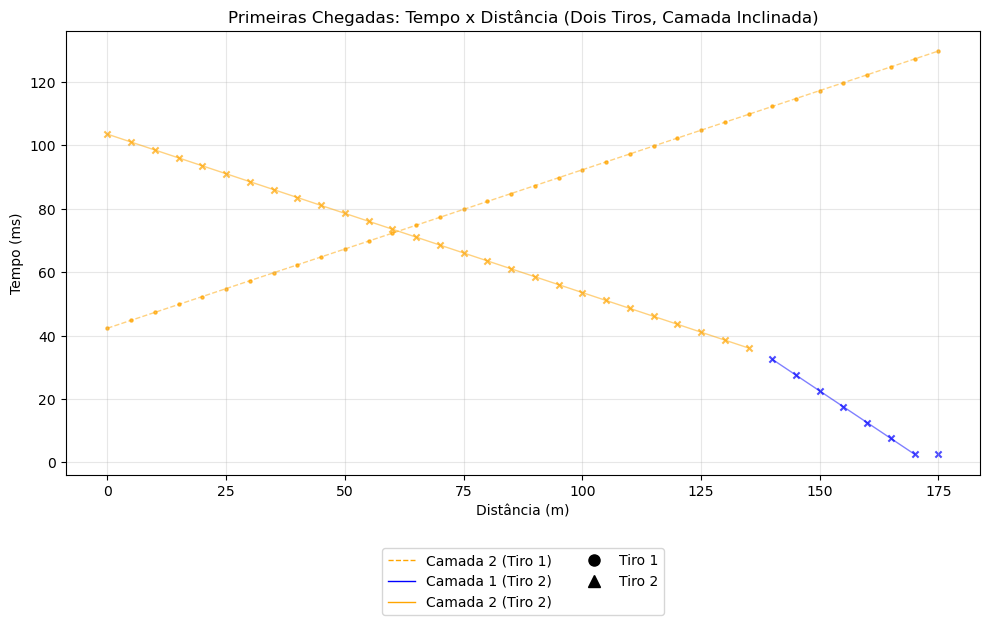

In [11]:
# Plota o gráfico tempo x distância
plot_first_arrivals(receiver_x, all_times, all_labels, layer_velocities, source_positions, receiver_spacing, num_receivers)


Perfil Geológico com os Dois Tiros:


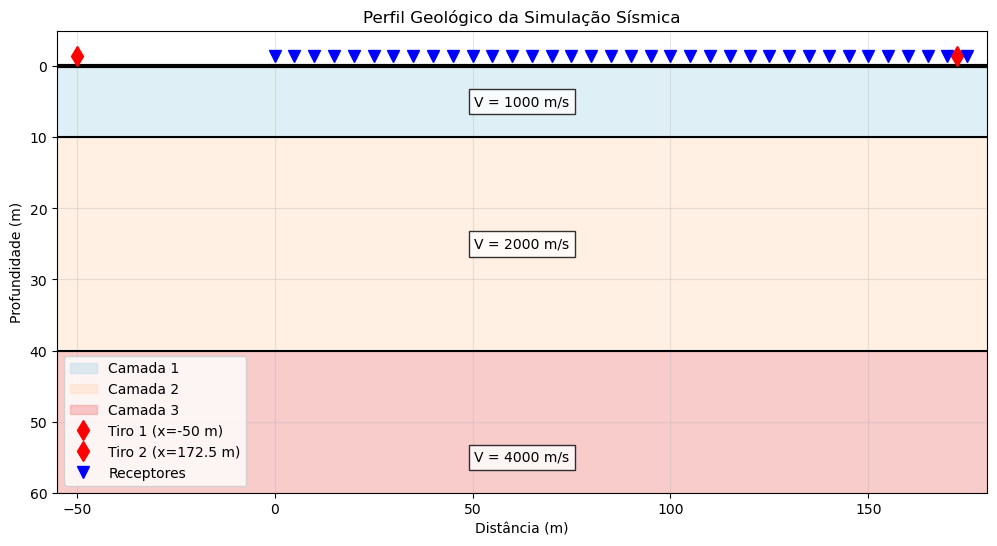

In [12]:
# Plota o perfil geológico com as duas fontes
print("\nPerfil Geológico com os Dois Tiros:")
plot_seismic_profile(layer_thickness, layer_velocities, layer_slopes, source_positions, receiver_positions)